In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import ot
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
import itertools
from EDRep_main.EDRep import NodeEmbedding
from functions import *

# Sanity Checks — Wasserstein Distance on DCSBM Graphs

This notebook verifies the fundamental properties of the $W_2$ graph distance based on EDRep embeddings.

Graphs are generated with the **Degree-Corrected Stochastic Block Model (DCSBM)**.

**Properties tested:**
1. **Identity** — $d(G, G) = 0$
2. **Symmetry** — $d(G_1, G_2) = d(G_2, G_1)$
3. **Triangle inequality** — $d(G_1, G_2) + d(G_2, G_3) \geq d(G_1, G_3)$
4. **Intra-class permutation invariance** — shuffling nodes within the same class does not change the distance
5. **Sensitivity to partition** — assigning nodes to the wrong class increases the distance
6. **Matched formula** — verifies the identity $d = \|X X^\top - Y Y^\top\|_F / \sqrt{2}$
7. **Node migration** — distance grows monotonically as nodes are moved between partitions

In [2]:
def block_dists(X_list):
    m = len(X_list)
    blocks = {}
    for i in range(m):
        for j in range(i, m):
            A = X_list[i] @ X_list[j].T
            if i == j:
                # intra-class: upper triangle only (symmetric, diagonal excluded)
                if A.shape[0] > 1:
                    vals = A[np.triu_indices_from(A, k=1)]
                else:
                    continue  # single-node class: no pairs to compare
            else:
                # inter-class: all pairwise products
                vals = A.flatten()
            blocks[(i, j)] = np.sort(vals)
    return blocks

def graph_distance(bd_a, bd_b):
    D = []
    for blk, va in bd_a.items():
        vb = bd_b.get(blk)
        if vb is not None:
            D.append(ot.wasserstein_1d(va, vb, p=2) ** 0.5)
    return np.linalg.norm(D)

## 1. Distance Functions

`block_dists(X_list)` — given a partitioned embedding, computes for each block pair $(i,j)$ the sorted distribution of scalar products $X_i X_j^\top$.

`graph_distance(bd_a, bd_b)` — compares the block distributions via 1D Wasserstein and returns the Euclidean norm of the per-block distances: $d = \left\| \left( W_2^{(i,j)} \right)_{i \leq j} \right\|_2$.

In [ ]:
def DCSBM(args):
    C, c, l_nodes, theta, symmetric, make_connected = args
    k = len(np.unique(l_nodes))
    n = len(theta)
    c_v = C[l_nodes].T
    fs, ss = [], []
    if symmetric:
        first = np.random.choice(n, int(n*c/2), p=theta/n)
    else:
        first = np.random.choice(n, int(n*c), p=theta/n)
    for i in range(k):
        v = theta * c_v[i]
        first_sel = first[l_nodes[first] == i]
        fs.append(first_sel.tolist())
        second_sel = np.random.choice(n, len(first_sel), p=v/np.sum(v))
        ss.append(second_sel.tolist())
    fs = np.array(list(itertools.chain(*fs)))
    ss = np.array(list(itertools.chain(*ss)))
    if make_connected:
        idx = np.arange(n)[~np.isin(np.arange(n), fs)]
        fs = np.concatenate([fs, idx])
        ss = np.concatenate([ss, np.argmax(theta) * np.ones(len(idx), dtype=int)])
    edge_list = np.unique(np.column_stack((fs, ss)), axis=0)
    mask = edge_list[:, 0] == edge_list[:, 1]
    edge_list[:, 1][mask] += 1
    edge_list[:, 1][edge_list[:, 1] == n] = 0
    if symmetric:
        M = np.maximum(edge_list[:, 0], edge_list[:, 1])
        m = np.minimum(edge_list[:, 0], edge_list[:, 1])
        df = pd.DataFrame({'i': np.concatenate([M, m]), 'j': np.concatenate([m, M])})
    else:
        df = pd.DataFrame({'i': edge_list[:, 0], 'j': edge_list[:, 1]})
    return df


def compute_cin_cout(c, k, alpha):
    c_out = c - alpha * np.sqrt(c)
    c_in = k * c - (k - 1) * c_out
    return c_in, c_out


def dcsbm_to_nx(df):
    n = int(max(df['i'].max(), df['j'].max())) + 1
    G = nx.Graph()
    G.add_nodes_from(range(n))          # forza ordine 0..n-1 in G.nodes()
    G.add_edges_from(zip(df['i'].astype(int), df['j'].astype(int)))
    return G

## 2. DCSBM Graph Generator

The **DCSBM** generates graphs with community structure controlled by parameter $\alpha$:

$$c_\text{out} = c - \alpha\sqrt{c}, \qquad c_\text{in} = kc - (k-1)\,c_\text{out}$$

- $\alpha = 0$: ER graph (no structure)
- Large $\alpha$: increasingly sharp communities ($c_\text{in} \gg c_\text{out}$)

`dcsbm_to_nx` explicitly adds nodes in order $0\ldots n-1$ before edges, ensuring that row $i$ of the adjacency matrix always corresponds to node $i$.

## 3. Graph Generation

Three graphs are generated with $n=1200$ nodes, $k=3$ balanced blocks (400 nodes each), and average degree $c=10$:

| Graph | Model | $\alpha$ | Structure |
|-------|-------|----------|-----------|
| $G_1$ | DCSBM | 1.5      | strong communities (seed 42) |
| $G_2$ | DCSBM | 1.5      | strong communities (seed 43) — *same model as $G_1$* |
| $G_3$ | DCSBM | 0.5      | weak communities |

$G_1$ and $G_2$ are independent draws from the **same** model → expected small distance.  
$G_3$ has a different structure → expected large distance.

In [4]:
# DCSBM parameters
n_nodes = 1200
k_sbm = 3
class_sizes = [n_nodes // k_sbm] * k_sbm   # [400, 400, 400]
c_avg = 10
symmetric = True
make_connected = True

theta = np.ones(n_nodes)
l_nodes = np.repeat(np.arange(k_sbm), n_nodes // k_sbm)

# Strong community structure (alpha=1.5)
c_in_1, c_out_1 = compute_cin_cout(c_avg, k_sbm, alpha=1.5)
C_1 = np.full((k_sbm, k_sbm), c_out_1)
np.fill_diagonal(C_1, c_in_1)

# Weaker community structure (alpha=0.5)
c_in_2, c_out_2 = compute_cin_cout(c_avg, k_sbm, alpha=0.5)
C_2 = np.full((k_sbm, k_sbm), c_out_2)
np.fill_diagonal(C_2, c_in_2)

np.random.seed(42); G_1 = dcsbm_to_nx(DCSBM((C_1, c_avg, l_nodes, theta, symmetric, make_connected)))
np.random.seed(43); G_2 = dcsbm_to_nx(DCSBM((C_1, c_avg, l_nodes, theta, symmetric, make_connected)))
np.random.seed(44); G_3 = dcsbm_to_nx(DCSBM((C_2, c_avg, l_nodes, theta, symmetric, make_connected)))

In [ ]:
embedding_dim= 32

def partition(class_sizes):
    part = []
    start = 0
    for i in class_sizes:
        part.append(list(range(start, start + i)))
        start += i
    return part

partitions= partition(class_sizes)
emb_1 = node_embedding(G_1, partitions, embedding_dim)
emb_2 = node_embedding(G_2, partitions, embedding_dim)
emb_3 = node_embedding(G_3, partitions, embedding_dim)


### EDRep Embeddings

Compute `NodeEmbedding` for each graph (`dim=32`, `k=1`) and slice the embedding matrix $X$ according to the ground-truth block partition.

In [6]:
bd_1 = block_dists(emb_1)
bd_2 = block_dists(emb_2)
bd_3 = block_dists(emb_3)

dist_G1_G1 = graph_distance(bd_1, bd_1)
dist_G1_G2 = graph_distance(bd_1, bd_2)
dist_G2_G1 = graph_distance(bd_2, bd_1)
dist_G1_G3 = graph_distance(bd_1, bd_3)
dist_G2_G3 = graph_distance(bd_3, bd_2)

## 4. Metric Properties

Verify that the distance satisfies the metric axioms:
- **Identity**: $d(G_1, G_1) = 0$
- **Symmetry**: $d(G_1, G_2) = d(G_2, G_1)$
- **Triangle inequality**: $d(G_1, G_2) + d(G_2, G_3) \geq d(G_1, G_3)$
- **Discriminativity**: graphs from the same model are close; graphs from different models are far apart

In [7]:
dist_G1_G2+dist_G2_G3>dist_G1_G3

np.True_

In [8]:
dist_G1_G1 = graph_distance(bd_1, bd_1)
dist_G1_G2 = graph_distance(bd_1, bd_2)
dist_G2_G1 = graph_distance(bd_2, bd_1)
dist_G1_G3 = graph_distance(bd_1, bd_3)

print(f"1. Identity d(G_1, G_1): {dist_G1_G1:.4f}")
print(f"2. Symmetry d(G_1, G_2): {dist_G1_G2:.4f} and d(G_2, G_1): {dist_G2_G1:.4f} ")
print(f"3. Distance between similar graphs d(G_1, G_2): {dist_G1_G2:.4f}")
print(f"4. Distance between very different graphs d(G_1, G_3): {dist_G1_G3:.4f}")

1. Identity d(G_1, G_1): 0.0000
2. Symmetry d(G_1, G_2): 0.0346 and d(G_2, G_1): 0.0346 
3. Distance between similar graphs d(G_1, G_2): 0.0346
4. Distance between very different graphs d(G_1, G_3): 0.1278


## 5. Partition Permutation Invariance

The distance must be **invariant under intra-class permutations** (shuffling nodes within the same class changes nothing) but **sensitive to inter-class permutations** (assigning nodes to the wrong class must increase the distance).

In [20]:
def intra_class_perm(partitions):
    perm_partitions = []
    for p in partitions:
        perm_partitions.append(list(np.random.permutation(p)))
    return perm_partitions


perm_partition = intra_class_perm(partitions)
emb_1_perm = node_embedding(G_1, perm_partition, embedding_dim)
dist_G1_G1perm = graph_distance(bd_1, block_dists(emb_1_perm))
print(dist_G1_G1perm)

2.3656095260053984e-17


### 5a. Intra-class permutation

Each class is shuffled internally. Expected distance $\approx 0$.

In [10]:
def inter_class_perm(G, partitions):
    class_size = [len(p) for p in partitions]
    shuffled_nodes = list(np.random.permutation(list(G.nodes())))

    new_partitions = []
    for i in partition(class_size):
        new_class = [shuffled_nodes[i] for i in i]
        new_partitions.append(new_class)

    return new_partitions

inter_perm_partition = inter_class_perm(G_1, partitions)
emb_1_inter_perm = node_embedding(G_1, inter_perm_partition, embedding_dim)
dist_G1_G1inter_perm = graph_distance(bd_1, block_dists(emb_1_inter_perm))
print(dist_G1_G1inter_perm)

0.1147268067994218


### 5b. Inter-class permutation

Nodes are randomly redistributed across classes (completely wrong partition). Expected large distance — proportional to the strength of the community structure.

In [11]:
inter_perm_partition3 = inter_class_perm(G_3, partitions)
emb_3_inter_perm = node_embedding(G_3, inter_perm_partition3, embedding_dim)
dist_G3_G3inter_perm = graph_distance(bd_3, block_dists(emb_3_inter_perm))
print(dist_G3_G3inter_perm)

0.009315706624433085


On $G_3$ (weak communities, $\alpha=0.5$) the inter-class distance is smaller: the community structure is less pronounced, so a wrong partition has less impact.

## 6. Matched Formula (singleton partition)

When each node is its own partition (singleton), the distance admits a closed form:

$$d(G_1, G_2) = \frac{\|X X^\top - Y Y^\top\|_F}{\sqrt{2}}$$

where $X, Y \in \mathbb{R}^{n \times d}$ are the embedding matrices of $G_1$ and $G_2$.

Two 2-block DCSBM graphs with different $\alpha$ values are used to ensure non-trivial embeddings ($k=1$ / ER would produce identical embeddings for all nodes, yielding distance $= 0$).

In [ ]:
def rand_graph_one_in_every_part(n, c, alpha):
    """2-block DCSBM con singleton partitions. alpha controlla la forza delle comunità."""
    k = 2
    theta = np.ones(n)
    l_nodes = np.repeat(np.arange(k), n // k)
    c_in, c_out = compute_cin_cout(c, k, alpha)
    C = np.full((k, k), c_out)
    np.fill_diagonal(C, c_in)
    df = DCSBM((C, c, l_nodes, theta, True, True))
    G_random = dcsbm_to_nx(df)
    partition_random = [[i] for i in range(n)]
    return G_random, partition_random

In [ ]:
G1, part1 = rand_graph_one_in_every_part(500, 10, alpha=1.5)  # comunità forti
G2, part2 = rand_graph_one_in_every_part(500, 10, alpha=0.5)  # comunità deboli

In [22]:
Embedding1 = node_embedding(G1, part1, 32)
Embedding2 = node_embedding(G2, part2, 32)

dist_G1G2 = graph_distance(block_dists(Embedding1), block_dists(Embedding2))
print(dist_G1G2)

110.46470962620452


### Verification: `graph_distance` must match the Frobenius norm formula

In [15]:
x=np.array([e[0] for e in Embedding1])
y=np.array([e[0] for e in Embedding2])
np.linalg.norm(x@x.T-y@y.T)/math.sqrt(2)

np.float64(110.46470962620452)

## 7. Node Migration Between Partitions

A 2-block DCSBM graph ($n=1000$, $\alpha=1.5$) is used with the **true partition** as reference ($d=0$).

Nodes are progressively moved from block 0 to block 1 (one at a time) and the distance from the original partition is tracked. The expected behaviour is a **monotonically increasing** curve.

> **Note**: the loop stops when block 0 has fewer than `max(50, n_bi//10)` nodes. Below this threshold, the intra-block $(0,0)$ distribution has too few samples to estimate $W_2$ reliably (e.g. 50 nodes → 1,225 pairs vs 124,750 in the baseline), causing numerical instability.

In [ ]:
# 2-block DCSBM
n_bi = 500
k_bi = 2
theta_bi = np.ones(2 * n_bi)
l_bi = np.array([0] * n_bi + [1] * n_bi)

c_bi = 10
c_in_bi, c_out_bi = compute_cin_cout(c_bi, k_bi, alpha=1.5)
C_bi = np.full((k_bi, k_bi), c_out_bi)
np.fill_diagonal(C_bi, c_in_bi)

np.random.seed(42)
G_bi = dcsbm_to_nx(DCSBM((C_bi, c_bi, l_bi, theta_bi, symmetric, make_connected)))

# Compute the global embedding ONCE (graph never changes, only the partition slice does)
np.random.seed(42)
g_bi_sparse = nx.to_scipy_sparse_array(G_bi, format='csr')
emb_obj = NodeEmbedding(g_bi_sparse, dim=embedding_dim, k=1)
X_bi = emb_obj.X  # shape (2*n_bi, embedding_dim)

def slice_partition(X, part0, part1):
    return [X[part0, :], X[part1, :]]

Running the optimization for k = 1


In [47]:
part0_base = list(range(n_bi))
part1_base = list(range(n_bi, 2*n_bi))

emb_base = slice_partition(X_bi, part0_base, part1_base)
bd_base = block_dists(emb_base)
dist_self = graph_distance(bd_base, bd_base)
print(f"Distance to self: {dist_self:.6f}")

distances_migration = []
min_part0_size = max(50, n_bi // 10)   # ferma prima che il campione (0,0) diventi troppo piccolo

for k in range(n_bi):
    moved     = part0_base[:k]
    new_part0 = part0_base[k:]
    new_part1 = part1_base + moved

    if len(new_part0) < min_part0_size:
        break

    emb_k = slice_partition(X_bi, new_part0, new_part1)
    bd_k  = block_dists(emb_k)
    dist_k = graph_distance(bd_base, bd_k)
    distances_migration.append(dist_k)

Distance to self: 0.000000


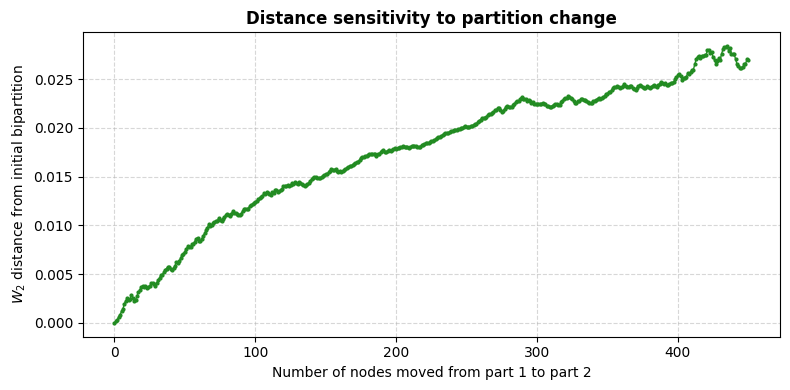

In [48]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(distances_migration)), distances_migration, marker='o', markersize=2, linewidth=1, color='forestgreen') 
plt.xlabel("Number of nodes moved from part 1 to part 2")
plt.ylabel("$W_2$ distance from initial bipartition")
plt.title("Distance sensitivity to partition change", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5);
plt.tight_layout()
plt.show()